# Sentiment Analysis and Visualization of Feedback Data

This notebook performs sentiment analysis on feedback data from 2019 dataset. It cleans the data, classifies sentiment based on a French dictionary, visualizes sentiment trends over time, and explores demographic patterns.

## 1. Install Necessary Libraries

We will start by installing the required libraries for text processing, sentiment analysis, and visualization.



In [ ]:
!pip install textblob_fr plotly wordcloud matplotlib pandas openpyxl nltk plotly

## 2. Import Libraries

Next, we will import all the necessary libraries for our analysis.

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from textblob import TextBlob
from textblob_fr import PatternTagger, PatternAnalyzer
import nltk
from nltk.corpus import stopwords
import plotly.express as px

## 3. Load French NLP Model

We will load the French language model for text processing and initialize the TextBlob for sentiment analysis.

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords

# Set of French stopwords
french_stopwords = set(stopwords.words('french'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 4. Load the Datasets

We will load the specific sheets from the Excel file containing feedback data.

In [ ]:
# Load the datasets
challenge_dataset_path = '/content/Challenge dataset.xlsx'
df_Volontaire = pd.read_excel(challenge_dataset_path, sheet_name='Volontaire')

# Display dataset information
print("\nVolontaire Dataset:")
print(df_Volontaire.info())


Volontaire Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1846 entries, 0 to 1845
Data columns (total 40 columns):
 #   Column                                                                                     Non-Null Count  Dtype  
---  ------                                                                                     --------------  -----  
 0   ID                                                                                         1846 non-null   object 
 1   Age                                                                                        1846 non-null   int64  
 2   Horodateur                                                                                 1846 non-null   object 
 3   Niveau_d'etude                                                                             1846 non-null   object 
 4   Genre_                                                                                     1846 non-null   object 
 5   Taille_                    

## 5. Check for Missing Values

Let's check for any missing values in all datasets to ensure data quality.

In [ ]:
# Check for missing values
print("\nMissing values in Volontaire dataset:")
print(df_Volontaire.isnull().sum())


Missing values in Volontaire dataset:
ID                                                                                              0
Age                                                                                             0
Horodateur                                                                                      0
Niveau_d'etude                                                                                  0
Genre_                                                                                          0
Taille_                                                                                      1786
Poids                                                                                        1742
Situation_Matrimoniale_(SM)                                                                     0
Profession_                                                                                     0
Arrondissement_de_résidence_                                                   

In [ ]:
# Drop rows where 'Si autres raison préciser' is NaN
df_Volontaire = df_Volontaire.dropna(subset=['Si_autres_raison_préciser_'])

## 8. Sentiment Analysis

We will classify the sentiment of the cleaned feedback into positive, negative, or neutral categories using the TextBlob French model. This model uses a predefined sentiment dictionary to classify sentiments after preprocessing.

In [ ]:
responses = df_Volontaire['Si_autres_raison_préciser_'].dropna().tolist()

# Print the responses
for response in responses:
    print(response)

Aucune information 
EU UNE ENDOSCOPIE ( FIBROSCOPIE,  GASTROSCOPIE, COLOSCOPIE .......)
physiquement amorti
TRAITE PAR ACUPUNCTURE
Mal de nerf
PAS D INFORMATION SUR SON DOSSIER
Consommation de drogue 
MENOPOSÉ
ETE TRAITE PAR ACUPUNCTURE
EU UNE ENDOSCOPIE
DROGUES
maladie chronique, suivi medical regulier
ANGINE DE LA POITRINE ,ARTÉRITE , INFARCTUS DU MYOCARDE 


In [ ]:
# List of key negative medical terms
negative_terms = [
    'maladie', 'chronique', 'ARTÉRITE', 'infarctus', 'angine', 'nerf', 'douleur', 'mal',
    'fibroscopie', 'ENDOSCOPIE', 'gastroscopie', 'traitement', 'ACUPUNCTURE', 'drogue', 'consommation'
]

# Function to classify sentiment
def classify_sentiment(text):
    if isinstance(text, str):  # Only process if text is a string
        # Check for presence of negative terms
        if any(term in text for term in negative_terms):
            return 'Negative'
    return 'Neutral'  # Default to Neutral if no negative terms are present or if not a string

## 7. Clean and Preprocess Text

We will define a function to clean and preprocess the text data by removing special characters and stop words.

In [ ]:
def clean_and_filter_text(text):
    # Handle potential float values by converting to string
    if isinstance(text, float):
        text = str(text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Zéèêëàâôùç\s]', '', text)
    # Convert text to lowercase
    text = text.lower()
    # text = ' '.join(response for response in responses if response.lower() != 'NaN')  # Incorrect
    text = ' '.join([word for word in text.split() if word not in french_stopwords]) # Correct stopword removal
    return text


df_Volontaire['cleaned_feedback'] = df_Volontaire['Si_autres_raison_préciser_'].apply(clean_and_filter_text)

In [ ]:
# Apply the sentiment analysis to the 'cleaned_feedback' column
df_Volontaire['sentiment'] = df_Volontaire['cleaned_feedback'].apply(classify_sentiment)

# Drop any rows where sentiment is NaN
df_2019 = df_Volontaire.dropna(subset=['sentiment'])

# Count the occurrences of each sentiment
sentiment_counts = df_Volontaire['sentiment'].value_counts()

# Display the counts
print(sentiment_counts)

# Display entries for each sentiment category
for sentiment in sentiment_counts.index:
    print(f"\nEntries classified as {sentiment}:")
    print(df_Volontaire[df_Volontaire['sentiment'] == sentiment][['Si_autres_raison_préciser_', 'sentiment']])

sentiment
Neutral     7
Negative    6
Name: count, dtype: int64

Entries classified as Neutral:
             Si_autres_raison_préciser_ sentiment
2                   Aucune information    Neutral
287                 physiquement amorti   Neutral
311              TRAITE PAR ACUPUNCTURE   Neutral
882   PAS D INFORMATION SUR SON DOSSIER   Neutral
1202                           MENOPOSÉ   Neutral
1216         ETE TRAITE PAR ACUPUNCTURE   Neutral
1469                  EU UNE ENDOSCOPIE   Neutral

Entries classified as Negative:
                             Si_autres_raison_préciser_ sentiment
30    EU UNE ENDOSCOPIE ( FIBROSCOPIE,  GASTROSCOPIE...  Negative
658                                         Mal de nerf  Negative
1127                            Consommation de drogue   Negative
1497                                            DROGUES  Negative
1660          maladie chronique, suivi medical regulier  Negative
1733  ANGINE DE LA POITRINE ,ARTÉRITE , INFARCTUS DU...  Negative


## 9. Visualize Sentiment Distribution

We will create visualizations to show the distribution of sentiments in the 2019 dataset.

In [ ]:
# List unique responses and their corresponding sentiments
unique_responses = df_Volontaire[['Si_autres_raison_préciser_', 'sentiment']].drop_duplicates()

print("Unique Responses and Their Sentiments:")
print(unique_responses)

Unique Responses and Their Sentiments:
                             Si_autres_raison_préciser_ sentiment
2                                   Aucune information    Neutral
30    EU UNE ENDOSCOPIE ( FIBROSCOPIE,  GASTROSCOPIE...  Negative
287                                 physiquement amorti   Neutral
311                              TRAITE PAR ACUPUNCTURE   Neutral
658                                         Mal de nerf  Negative
882                   PAS D INFORMATION SUR SON DOSSIER   Neutral
1127                            Consommation de drogue   Negative
1202                                           MENOPOSÉ   Neutral
1216                         ETE TRAITE PAR ACUPUNCTURE   Neutral
1469                                  EU UNE ENDOSCOPIE   Neutral
1497                                            DROGUES  Negative
1660          maladie chronique, suivi medical regulier  Negative
1733  ANGINE DE LA POITRINE ,ARTÉRITE , INFARCTUS DU...  Negative


In [ ]:
# Visualize sentiment distribution
def plot_sentiment_distribution(df, title):
    sentiment_count = df['sentiment'].value_counts().reset_index()
    sentiment_count.columns = ['Sentiment', 'Count']

    fig = px.bar(sentiment_count, x='Sentiment', y='Count',
                 title=title, color='Sentiment',
                 labels={'Sentiment': 'Sentiment', 'Count': 'Number of Responses'},
                 hover_data=['Count'])
    fig.show()

plot_sentiment_distribution(df_Volontaire, 'Sentiment Distribution in Volontaire Dataset')

## 13. Plot Sentiment by Demographic Groups

We will explore how sentiments vary across different demographic groups by creating bar charts.

In [ ]:
def plot_sentiment_by_demographics(df, demographic_col, title):
    sentiment_by_demo = df.groupby(demographic_col)['sentiment'].value_counts().unstack(fill_value=0)

    # Plotting a bar chart for each demographic group
    sentiment_by_demo.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(title)
    plt.xlabel(demographic_col)
    plt.ylabel('Count of Sentiments')
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()

## 14. Plot for Different Demographic Groups

Now we will plot sentiment distributions by various demographics in the 2019 dataset.

<ipython-input-14-893e1f76c717>:21: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



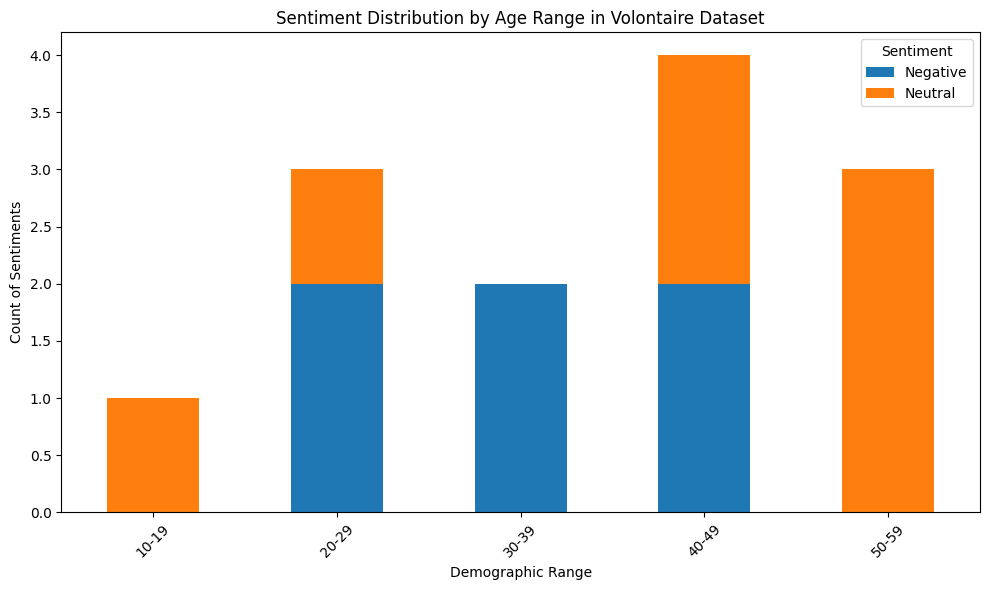

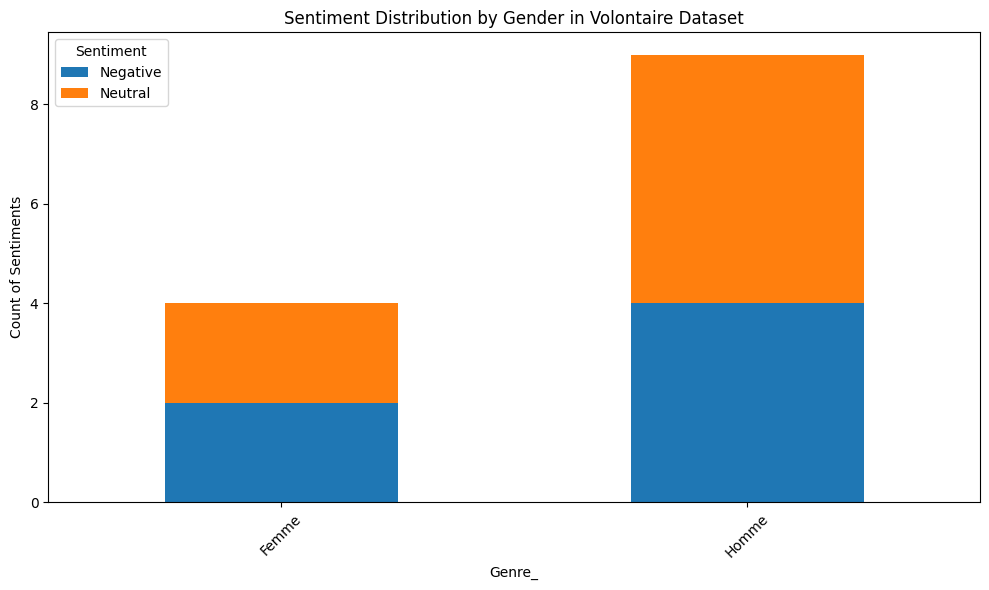

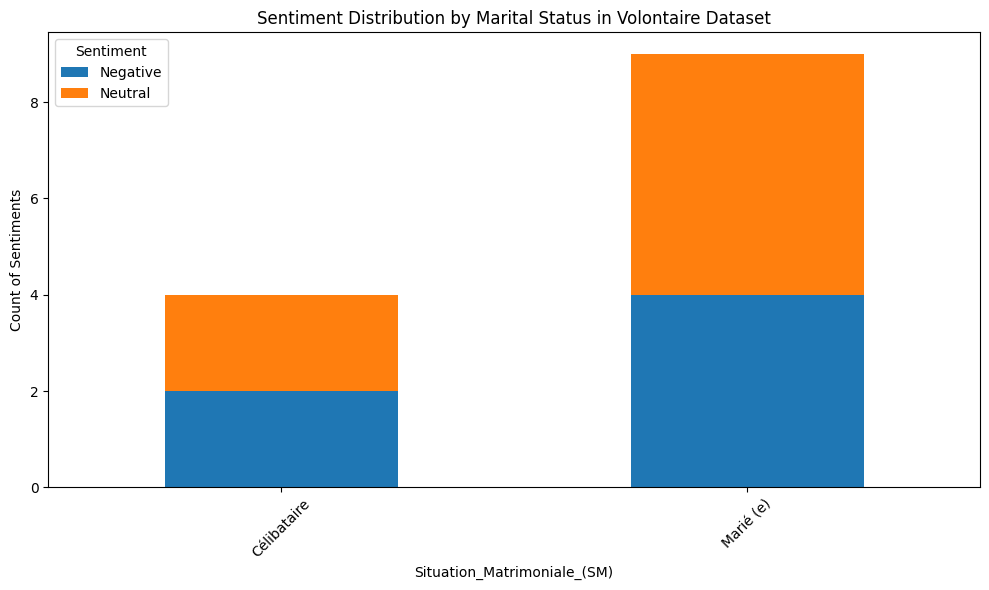

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_sentiment_by_demographics(df, demographic_col, title):
    # Check if the demographic column is numeric
    if pd.api.types.is_numeric_dtype(df[demographic_col]):
        # Create bins based on min and max values
        min_age = df[demographic_col].min()
        max_age = df[demographic_col].max() + 1  # Include the maximum age
        bins = list(range(min_age // 10 * 10, max_age + 10, 10))
        # Adjust labels to match the number of bins
        # The issue was with bin and label counts not matching
        # This line ensures there's always one fewer label than bins:
        labels = [f'{i}-{i+9}' for i in bins[:-1]]

        # Apply pd.cut to create the demographic ranges
        df['Demographic Range'] = pd.cut(df[demographic_col], bins=bins, labels=labels, right=False, include_lowest=True, duplicates='drop')
        demographic_col = 'Demographic Range'  # Update to use the new column name

    #Group by the demographic column and count sentiments
    sentiment_distribution = df.groupby(demographic_col)['sentiment'].value_counts().unstack(fill_value=0)

    # Plotting the sentiment distribution
    sentiment_distribution.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(title)
    plt.xlabel(demographic_col)
    plt.ylabel('Count of Sentiments')
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()

# Apply to the Volontaire dataset
plot_sentiment_by_demographics(df_Volontaire, 'Age', 'Sentiment Distribution by Age Range in Volontaire Dataset')
plot_sentiment_by_demographics(df_Volontaire, 'Genre_', 'Sentiment Distribution by Gender in Volontaire Dataset')
plot_sentiment_by_demographics(df_Volontaire, 'Situation_Matrimoniale_(SM)', 'Sentiment Distribution by Marital Status in Volontaire Dataset')

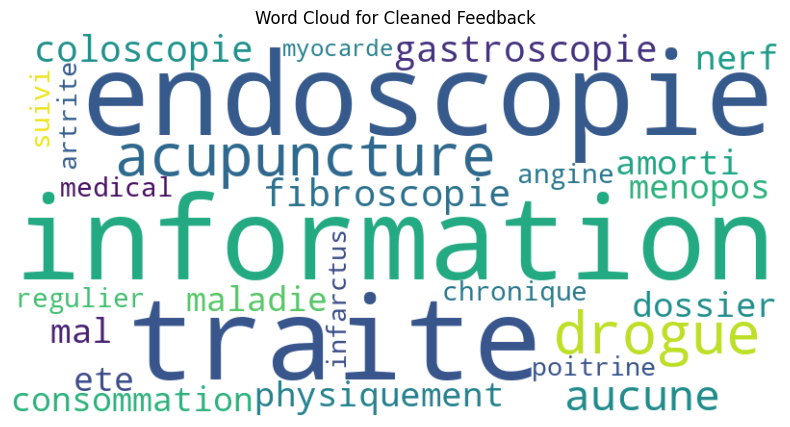

In [ ]:
def generate_wordcloud(df):
    combined_feedback = ' '.join(df['cleaned_feedback'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combined_feedback)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud for Cleaned Feedback')
    plt.show()

generate_wordcloud(df_Volontaire)